In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import json
from sklearn.preprocessing import StandardScaler
import lemminflect

# Pretrained Vectors

In [1]:
from gensim.models import KeyedVectors
import gensim.downloader
print(list(gensim.downloader.info()['models'].keys()))

gensim.downloader.load("word2vec-google-news-300")
gensim.downloader.load("glove-wiki-gigaword-300")

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']
[===-----------------------------------------------] 7.2% 119.8/1662.8MB downloaded

KeyboardInterrupt: 

In [12]:
# Path to the pretrained model
path = "~/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz"

# Load the model
model = KeyedVectors.load_word2vec_format(path, binary=True)

In [18]:
with open("/sailhome/jjian/projects/abstraction/data/ditransitives.txt", "r") as f:
    ditransitives = f.readlines()

with open("/sailhome/jjian/projects/abstraction/data/motion.txt", "r") as f:
    motion = f.readlines()

ditransitives = [x.strip() for x in ditransitives]
motion = [x.strip() for x in motion]

In [19]:
import lemminflect

def get_inflections(word):
    infl = lemminflect.getAllInflections(word)
    return [x[0] for x in infl.values()]

ditransitives_inflections = []
for word in ditransitives:
    ditransitives_inflections.extend(get_inflections(word))

motion_inflections = []
for word in motion:
    motion_inflections.extend(get_inflections(word))
    

In [42]:
# get vectors for both ditransitive and motion from the model

ditransitive_vectors = [model[x] for x in ditransitives if x in model]
motion_vectors = [model[x] for x in motion if x in model]

print(len(ditransitive_vectors) == len(ditransitives))
print(len(motion_vectors) == len(motion))

True
True


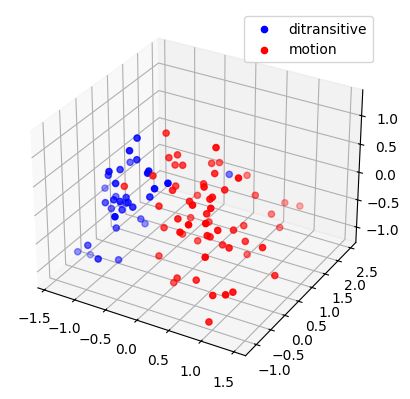

In [43]:
# run a pca then plot
pca = PCA(n_components=3)

# fit the pca
pca.fit(ditransitive_vectors + motion_vectors)

# transform the data
ditransitive_pca = pca.transform(ditransitive_vectors)
motion_pca = pca.transform(motion_vectors)

# 3D plot

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(ditransitive_pca[:, 0], ditransitive_pca[:, 1], ditransitive_pca[:, 2], c='b', label='ditransitive')
ax.scatter(motion_pca[:, 0], motion_pca[:, 1], motion_pca[:, 2], c='r', label='motion')

plt.legend()
plt.show()


In [15]:
import spacy

In [16]:
nlp = spacy.load("/sailhome/jjian/projects/abstraction/glove_vecs")


In [21]:
ditransitive_vectors = [nlp(x).vector for x in ditransitives_inflections]
motion_vectors = [nlp(x).vector for x in motion_inflections]

print(len(ditransitive_vectors) == len(ditransitives))
print(len(motion_vectors) == len(motion))

False
False


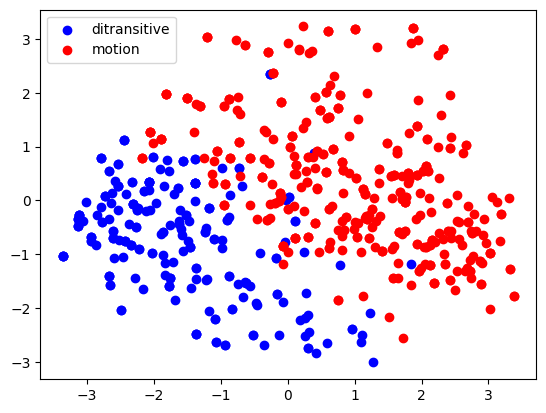

In [67]:
# plot 2D pca

# plot in 2D

pca = PCA(n_components=4)

# fit the pca
pca.fit(ditransitive_vectors + motion_vectors)

# transform the data
ditransitive_pca = pca.transform(ditransitive_vectors)
motion_pca = pca.transform(motion_vectors)

plt.scatter(ditransitive_pca[:, 0], ditransitive_pca[:, 1], c='b', label='ditransitive')
plt.scatter(motion_pca[:, 0], motion_pca[:, 1], c='r', label='motion')

plt.legend()
plt.show()

# get the average in class and between class distances before and after pca



In [22]:
# get pairwise distances excluding self distances
ditransitive_distances = euclidean_distances(ditransitive_vectors, ditransitive_vectors)
motion_distances = euclidean_distances(motion_vectors, motion_vectors)

# get the average distance within class
ditransitive_within = np.mean(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
motion_within = np.mean(motion_distances[np.triu_indices(len(motion_distances), k=1)])

# get the average distance between class
ditransitive_motion_distances = euclidean_distances(ditransitive_vectors, motion_vectors)
between = np.mean(ditransitive_motion_distances)

print(ditransitive_within, motion_within, between)

# get the average distance within class after pca
ditransitive_distances = euclidean_distances(ditransitive_pca, ditransitive_pca)
motion_distances = euclidean_distances(motion_pca, motion_pca)

# get the average distance within class
ditransitive_within = np.mean(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
motion_within = np.mean(motion_distances[np.triu_indices(len(motion_distances), k=1)])
# get the standard deviation of the distances
ditransitive_within_std = np.std(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
motion_within_std = np.std(motion_distances[np.triu_indices(len(motion_distances), k=1)])
# get the average distance between class
ditransitive_motion_distances = euclidean_distances(ditransitive_pca, motion_pca)
between = np.mean(ditransitive_motion_distances)
# get the standard deviation of the distances
between_std = np.std(ditransitive_motion_distances)


# format and print with std
print(f"Within class ditransitive: {ditransitive_within:.2f} +/- {ditransitive_within_std:.2f}")
print(f"Within class motion: {motion_within:.2f} +/- {motion_within_std:.2f}")
print(f"Between class: {between:.2f} +/- {between_std:.2f}")


7.921433 8.124406 8.531528


NameError: name 'ditransitive_pca' is not defined

In [2]:
import json
from collections import Counter

In [6]:
ditrans_preds = json.load(open("/nlp/scr/jjian/data/wikitext/ditrans_annotated/predictions/preposition_fragment/battlestar-gpt2-small-x49.checkpoint-400000.predictions.json", "r"))
motion_preds = json.load(open("/nlp/scr/jjian/data/wikitext/motion_annotated/predictions/preposition_fragment/battlestar-gpt2-small-x49.checkpoint-400000.predictions.json", "r"))
ditrans_verbs = [x["top_k_tokens"][0][0] for x in ditrans_preds if len(x["top_k_tokens"]) > 0]
motion_verbs = [x["top_k_tokens"][0][0] for x in motion_preds if len(x["top_k_tokens"]) > 0]

In [7]:
ditrans_verbs = Counter(ditrans_verbs)
motion_verbs = Counter(motion_verbs)

In [11]:
ditrans_minus_motion = ditrans_verbs - motion_verbs
motion_minus_ditrans = motion_verbs - ditrans_verbs

In [15]:
print(ditrans_minus_motion.most_common(15))
print(motion_minus_ditrans.most_common(15))

[(' public', 123), (' children', 58), (' audience', 47), (' people', 46), (' company', 36), (' family', 36), (' New', 35), (' British', 35), (' player', 25), (' state', 23), (' team', 22), (' new', 21), (' best', 21), (' police', 21), (' world', 21)]
[(' top', 167), (' front', 112), (' surface', 100), (' United', 96), (' hospital', 88), (' scene', 61), (' ground', 52), (' door', 38), (' airport', 33), (' north', 32), (' finish', 29), (' bottom', 28), (' south', 26), (' west', 25), (' sea', 24)]


In [20]:
print(ditrans_top_verbs + motion_top_verbs)

['public', 'children', 'audience', 'people', 'company', 'family', 'New', 'British', 'player', 'state', 'team', 'new', 'best', 'police', 'world', 'top', 'front', 'surface', 'United', 'hospital', 'scene', 'ground', 'door', 'airport', 'north', 'finish', 'bottom', 'south', 'west', 'sea']


In [18]:
ditrans_top_verbs = [x[0].strip() for x in ditrans_minus_motion.most_common(15)]
motion_top_verbs = [x[0].strip() for x in motion_minus_ditrans.most_common(15)]

with open("/sailhome/jjian/projects/abstraction/data/ditrans_400000_top15.txt", "w") as f:
    f.write("\n".join(ditrans_top_verbs))

with open("/sailhome/jjian/projects/abstraction/data/motion_400000_top15.txt", "w") as f:
    f.write("\n".join(motion_top_verbs))

# Our Vectors

In [2]:
ditrans_keys = [[31935], [19171], [36836, 689], [477, 27123], [47405], [477, 1747], [44554], [47405, 889], [1265], [1965], [4737], [7893], [8333], [8686], [38875], [46974], [5764], [11343], [46116], [13304], [307, 4188, 776], [307, 421, 4098, 704], [307, 421, 4098, 722], [307, 4188, 33148], [269, 18654], [269, 15395], [269, 37507], [269, 8228], [5203], [6793], [13630], [16316], [6699], [18866], [10129], [17086], [27861], [34756], [35054], [8633, 803], [4727], [4893], [11170], [6688], [11672], [3745], [13017], [21318], [2651], [28308], [43448], [22052], [2921], [1577], [1813], [3607], [3501], [7264], [7520], [21787], [11455], [9149], [11462], [50156], [19026], [2071], [4884], [2428], [19089], [15278], [40352], [38522], [42150], [6920], [37789], [21898], [285, 1768], [2897], [4438], [6011], [4394], [3432], [1208], [3804], [8318], [6427], [1414], [5989], [13831], [1944], [5545], [17728], [10969], [6991], [8072], [10497], [11781], [1100], [3555], [9743], [12929], [12929, 276], [12929, 278], [36903], [823, 1698], [24248], [47968], [823, 8369], [823, 592], [5602], [26399], [34245], [28393], [3677], [6301], [16015], [905], [3751], [4478], [3402], [2523], [2702], [7817], [4545], [17324], [7743], [1560], [5149], [4952], [1297], [3292], [14018], [17674], [7313], [4351], [11172], [26140], [16395], [7800], [26403], [39127], [19299]]
motion_keys = [[9240], [5284], [14443], [14820], [34800], [44440], [41988], [10570, 2412], [7161], [275, 17951], [16715], [38088], [47434], [460, 78, 276], [47434, 278], [460, 3028], [15505], [26172], [442, 1386], [20023], [12080], [19952], [14281], [34332], [27318], [45668], [34499], [27784, 7278], [13972], [38598], [49100], [47092], [3272], [12606], [24234], [12538], [6772], [11700, 276], [16006], [16259], [35970], [288, 19112], [35970, 278], [47807], [14470], [37901], [288, 7465], [288, 2140], [6313], [24057], [37717], [1207, 5889], [15350], [23667], [31491], [1715, 2412], [24260], [38648], [38193], [1553, 19265], [8420], [34710], [33895], [30151], [11468], [11562], [19105], [5104, 274], [13112], [17607], [12178], [29742], [12462], [36016], [22371], [6129], [7348], [7976, 404], [7976, 19458], [7976, 15816], [7976, 2840], [48089], [1278, 1384], [1278, 1460], [1278, 2530], [467], [2925], [1016], [3750], [19338, 268], [19338, 2945], [19338, 3101], [19338, 641], [18390], [289, 17951], [34309], [24522], [1725], [45230], [47153], [29438], [31662], [6990, 1678], [23290], [6990, 14992], [11111], [753, 704], [8331], [287, 10813], [7002], [7002, 276], [30068, 710, 1112], [35724], [34681, 461], [34681, 4335], [34681, 868], [34681, 4730], [42102], [1761, 9124], [1761, 13886], [1761, 862], [300, 2575], [20605, 1740], [300, 12730], [300, 2575, 278], [9960], [23558], [36963], [26409], [502, 4066], [502, 392, 1068], [502, 42454], [502, 45070], [39517], [14098, 992], [14098, 829], [14098, 1359], [32669], [31460], [41904, 274], [41904, 278], [3234], [32897], [9558], [11717], [31812], [31812, 276], [31812, 278], [31812, 82], [4966], [46715], [6594], [17445], [10311], [22075], [5752], [5752, 276], [686, 5469], [15274], [1057], [2491], [4539], [10484], [13999], [38596], [15795], [14936], [33835], [28499], [48370], [36755], [34351], [16701, 7689], [36502], [629, 333, 2228], [629, 333, 1678], [629, 16682], [629, 333, 14992], [22647], [1341, 515], [1341, 689], [33051], [3993, 16783, 591], [3993, 16783, 591, 276], [3993, 16783, 591, 274], [3993, 16783, 591, 278], [40424], [2866], [26347], [12055], [20778], [48480], [23508], [35251, 5355], [965, 4651], [33769], [35002], [965, 2530], [9660, 2934], [35174], [24241], [336, 25329], [37829], [1509, 321], [9422], [14899], [9422, 82], [1509, 388], [17536], [1687, 798], [17536, 278], [45049], [3067], [14113], [11300], [17781], [30784], [30784, 9091], [30784, 3364], [2054, 591], [4161, 83], [4161, 912], [4161, 28734], [4161, 83, 889], [491, 12587], [491, 463, 2004], [491, 463, 3212], [491, 38840], [47978], [256, 11137], [256, 25329], [256, 14739], [22563], [22563, 276], [22563, 278], [410, 13185], [2513], [6807], [6155], [11114], [27776], [36036], [24504], [11569, 364], [1816]]
ditrans_subwords = [[' allocate'], [' allocated'], [' alloc', 'ates'], [' all', 'ocating'], [' allot'], [' all', 'ots'], [' allotted'], [' allot', 'ting'], [' ask'], [' asked'], [' asking'], [' asks'], [' assign'], [' assigned'], [' assigning'], [' assigns'], [' award'], [' awarded'], [' awarding'], [' awards'], [' be', 'que', 'ath'], [' be', 'qu', 'eat', 'hed'], [' be', 'qu', 'eat', 'hing'], [' be', 'que', 'aths'], [' c', 'ede'], [' c', 'eded'], [' c', 'edes'], [' c', 'eding'], [' deliver'], [' delivered'], [' delivering'], [' delivers'], [' denied'], [' denies'], [' deny'], [' denying'], [' dictate'], [' dictated'], [' dictates'], [' dict', 'ating'], [' explain'], [' explained'], [' explaining'], [' explains'], [' fed'], [' feed'], [' feeding'], [' feeds'], [' forward'], [' forwarded'], [' forwarding'], [' forwards'], [' gave'], [' give'], [' given'], [' gives'], [' giving'], [' grant'], [' granted'], [' granting'], [' grants'], [' guarantee'], [' guaranteed'], [' guaranteeing'], [' guarantees'], [' issue'], [' issued'], [' issues'], [' issuing'], [' lease'], [' leased'], [' leases'], [' leasing'], [' mail'], [' mailed'], [' mailing'], [' m', 'ails'], [' offer'], [' offered'], [' offering'], [' offers'], [' paid'], [' pass'], [' passed'], [' passes'], [' passing'], [' pay'], [' paying'], [' pays'], [' present'], [' presented'], [' presenting'], [' presents'], [' promise'], [' promised'], [' promises'], [' promising'], [' read'], [' reading'], [' reads'], [' refund'], [' refund', 'ed'], [' refund', 'ing'], [' refunds'], [' rel', 'aid'], [' relay'], [' relayed'], [' rel', 'aying'], [' rel', 'ays'], [' rent'], [' rented'], [' renting'], [' rents'], [' sell'], [' selling'], [' sells'], [' show'], [' showed'], [' showing'], [' shown'], [' shows'], [' sold'], [' taught'], [' teach'], [' teaches'], [' teaching'], [' tell'], [' telling'], [' tells'], [' told'], [' trade'], [' traded'], [' trades'], [' trading'], [' transfer'], [' transferred'], [' transferring'], [' transfers'], [' yield'], [' yielded'], [' yielding'], [' yields']]
motion_subwords = [[' arrive'], [' arrived'], [' arrives'], [' arriving'], [' ascend'], [' ascended'], [' ascending'], [' asc', 'ends'], [' bike'], [' b', 'iked'], [' bikes'], [' biking'], [' canoe'], [' can', 'o', 'ed'], [' canoe', 'ing'], [' can', 'oes'], [' chase'], [' chased'], [' ch', 'ases'], [' chasing'], [' climb'], [' climbed'], [' climbing'], [' climbs'], [' crawl'], [' crawled'], [' crawling'], [' craw', 'ls'], [' creep'], [' creeping'], [' creeps'], [' crept'], [' cross'], [' crossed'], [' crosses'], [' crossing'], [' cycle'], [' cycl', 'ed'], [' cycles'], [' cycling'], [' dart'], [' d', 'arted'], [' dart', 'ing'], [' darts'], [' dash'], [' dashed'], [' d', 'ashes'], [' d', 'ashing'], [' depart'], [' departed'], [' departing'], [' dep', 'arts'], [' descend'], [' descended'], [' descending'], [' desc', 'ends'], [' drift'], [' drifted'], [' drifting'], [' dr', 'ifts'], [' exit'], [' exited'], [' exiting'], [' exits'], [' fled'], [' flee'], [' fleeing'], [' fle', 'es'], [' flew'], [' flies'], [' float'], [' floated'], [' floating'], [' floats'], [' flown'], [' fly'], [' flying'], [' gall', 'op'], [' gall', 'oped'], [' gall', 'oping'], [' gall', 'ops'], [' glide'], [' gl', 'ided'], [' gl', 'ides'], [' gl', 'iding'], [' go'], [' goes'], [' going'], [' gone'], [' hast', 'en'], [' hast', 'ened'], [' hast', 'ening'], [' hast', 'ens'], [' hike'], [' h', 'iked'], [' hikes'], [' hiking'], [' hop'], [' hopped'], [' hopping'], [' hops'], [' hurried'], [' hur', 'ries'], [' hurry'], [' hur', 'rying'], [' inch'], [' inc', 'hed'], [' inches'], [' in', 'ching'], [' journey'], [' journey', 'ed'], [' jour', 'ne', 'ying'], [' journeys'], [' kay', 'ak'], [' kay', 'aked'], [' kay', 'aking'], [' kay', 'aks'], [' limp'], [' lim', 'ped'], [' lim', 'ping'], [' lim', 'ps'], [' l', 'urch'], [' lur', 'ched'], [' l', 'urches'], [' l', 'urch', 'ing'], [' march'], [' marched'], [' marches'], [' marching'], [' me', 'ander'], [' me', 'and', 'ered'], [' me', 'andering'], [' me', 'anders'], [' paddle'], [' padd', 'led'], [' padd', 'les'], [' padd', 'ling'], [' plunge'], [' plunged'], [' plung', 'es'], [' plung', 'ing'], [' race'], [' raced'], [' races'], [' racing'], [' raft'], [' raft', 'ed'], [' raft', 'ing'], [' raft', 's'], [' ran'], [' ridden'], [' ride'], [' rides'], [' riding'], [' rode'], [' row'], [' row', 'ed'], [' ro', 'wing'], [' rows'], [' run'], [' running'], [' runs'], [' rush'], [' rushed'], [' rushes'], [' rushing'], [' sail'], [' sailed'], [' sailing'], [' sails'], [' scramble'], [' scrambled'], [' scram', 'bles'], [' scrambling'], [' sc', 'ur', 'ried'], [' sc', 'ur', 'ries'], [' sc', 'urry'], [' sc', 'ur', 'rying'], [' skate'], [' sk', 'ated'], [' sk', 'ates'], [' skating'], [' sleep', 'wal', 'ks'], [' sleep', 'wal', 'ks', 'ed'], [' sleep', 'wal', 'ks', 'es'], [' sleep', 'wal', 'ks', 'ing'], [' sped'], [' speed'], [' speeding'], [' speeds'], [' stagger'], [' staggered'], [' staggering'], [' stag', 'gers'], [' str', 'idden'], [' stride'], [' strides'], [' str', 'iding'], [' stro', 'de'], [' stumble'], [' stumbled'], [' st', 'umbles'], [' stumbling'], [' sw', 'am'], [' swim'], [' swimming'], [' swim', 's'], [' sw', 'um'], [' taxi'], [' tax', 'ied'], [' taxi', 'ing'], [' taxis'], [' travel'], [' traveled'], [' traveling'], [' travels'], [' trek'], [' trek', 'ked'], [' trek', 'king'], [' tre', 'ks'], [' tro', 't'], [' tro', 'ts'], [' tro', 'tted'], [' tro', 't', 'ting'], [' tr', 'udge'], [' tr', 'ud', 'ged'], [' tr', 'ud', 'ges'], [' tr', 'udging'], [' tumble'], [' t', 'umbled'], [' t', 'umbles'], [' t', 'umbling'], [' vault'], [' vault', 'ed'], [' vault', 'ing'], [' v', 'aults'], [' walk'], [' walked'], [' walking'], [' walks'], [' wander'], [' wandered'], [' wandering'], [' wand', 'ers'], [' went']]

ditrans_mono = [x[0] for x in ditrans_keys if len(x) == 1]
motion_mono = [24057, 36755, 45668, 23558, 6594, 15274, 4539, 34351, 7002, 2491, 37829, 49100, 9422, 5284, 3272, 38598, 24234, 6807, 1057, 35174, 39517, 15505, 32669, 18390, 24241, 10484, 12462, 11562, 48089, 24522, 48480, 23290, 14443, 5752, 4966, 14281, 2925, 11468, 31662, 17607, 26172, 15795, 14936, 47978, 34800, 13972, 22371, 10311, 11300, 11114, 1016, 45049, 38648, 40424, 37901, 13999, 41988, 26409, 38596, 9558, 12538, 6313, 48370, 17781, 27776, 3234, 12080, 31460, 23667, 29742, 36036, 11111, 46715, 38193, 24260, 34332, 6772, 8331, 2513, 14899, 16259, 31491, 12178, 467, 33051, 20778, 44440, 34499, 11717, 27318, 24504, 6129, 12606, 26347, 1816, 13112, 6155, 14113, 37717, 14470, 22647, 34309, 14820, 19952, 17445, 36016, 16006, 15350, 9960, 36502, 12055, 35724, 28499, 33835, 2866, 36963, 20023, 32897, 7348, 19105, 47092, 22075, 9240, 3067, 23508, 42102, 17536, 3750]

ditrans_mono_subwords = [x[0] for x in ditrans_subwords if len(x) == 1]
motion_mono_subwords = [' arrive', ' arrived', ' arrives', ' arriving', ' ascend', ' ascended', ' ascending', ' chase', ' chased', ' chasing', ' climb', ' climbed', ' climbing', ' climbs', ' crawl', ' crawled', ' crawling', ' creep', ' creeping', ' creeps', ' crept', ' cross', ' crossed', ' crosses', ' crossing', ' cycle', ' cycles', ' cycling', ' dash', ' dashed', ' depart', ' departed', ' departing', ' descend', ' descended', ' descending', ' drift', ' drifted', ' drifting', ' fled', ' flee', ' fleeing', ' flew', ' flies', ' float', ' floated', ' floating', ' floats', ' flown', ' fly', ' flying', ' glide', ' go', ' goes', ' going', ' gone', ' hike', ' hikes', ' hiking', ' hurried', ' hurry', ' inch', ' inches', ' journey', ' journeys', ' limp', ' march', ' marched', ' marches', ' marching', ' paddle', ' plunge', ' plunged', ' race', ' raced', ' races', ' racing', ' ran', ' ridden', ' ride', ' rides', ' riding', ' rode', ' row', ' rows', ' run', ' running', ' runs', ' rush', ' rushed', ' rushes', ' rushing', ' sail', ' sailed', ' sailing', ' sails', ' scramble', ' scrambled', ' scrambling', ' skate', ' skating', ' sped', ' speed', ' speeding', ' speeds', ' stagger', ' staggered', ' staggering', ' stumble', ' stumbled', ' stumbling', ' swim', ' swimming', ' taxi', ' taxis', ' travel', ' traveled', ' traveling', ' travels', ' tumble', ' walk', ' walked', ' walking', ' walks', ' wander', ' wandered', ' wandering', ' went']

motion_mono_lemmas = [lemminflect.getLemma(x.strip(), "VERB")[0] for x in motion_mono_subwords]
all_lemmas = set(motion_mono_lemmas)
all_lemmas = list(all_lemmas)
all_lemmas.sort()
# combine into a list of tuples of indices with the same lemma
motion_inflections_to_avg = [[] for _ in range(len(all_lemmas))]
for i, lemma in enumerate(all_lemmas):
    for j, inflection in enumerate(motion_mono_lemmas):
        if inflection == lemma:
            motion_inflections_to_avg[i].append(j)
motion_inflections_to_avg = list(zip(all_lemmas, motion_inflections_to_avg))
ditrans_mono_lemmas = [lemminflect.getLemma(x.strip(), "VERB")[0] for x in ditrans_mono_subwords]
all_lemmas = set(ditrans_mono_lemmas)
all_lemmas = list(all_lemmas)
all_lemmas.sort()
# combine into a list of tuples of indices with the same lemma
ditrans_inflections_to_avg = [[] for _ in range(len(all_lemmas))]
for i, lemma in enumerate(all_lemmas):
    for j, inflection in enumerate(ditrans_mono_lemmas):
        if inflection == lemma:
            ditrans_inflections_to_avg[i].append(j)
ditrans_inflections_to_avg = list(zip(all_lemmas, ditrans_inflections_to_avg))

In [3]:
cosine_ditrans_avg = []
cosine_motion_avg = []
cosine_between_avg = []

separability = []
svd_last = np.load(f"/nlp/scr/jjian/datasets/openwebtext_filtered/word_vectors_earliest/openwebtext_co_matrix_02.svd_l.propack.npy")
svd_ditrans_last = [svd_last[x] for x in ditrans_mono]
svd_motion_last = [svd_last[x] for x in motion_mono]

pca = PCA(n_components=10)
pca.fit(svd_ditrans_last + svd_motion_last)
for i in range(2, 112, 2):
    svd_vectors_0 = np.load(f"/nlp/scr/jjian/datasets/openwebtext_filtered/word_vectors/openwebtext_co_matrix_0{i}.svd_l.propack.npy")
    svd_ditrans_0 = [svd_vectors_0[x] for x in ditrans_mono]
    svd_motion_0 = [svd_vectors_0[x] for x in motion_mono]
    # partition the vectors into inflections with the same lemma
    svd_ditrans_0 = [np.mean([svd_ditrans_0[x] for x in indices[1]], axis=0) for indices in ditrans_inflections_to_avg]
    svd_motion_0 = [np.mean([svd_motion_0[x] for x in indices[1]], axis=0) for indices in motion_inflections_to_avg]
    pca = PCA(n_components=2)
    # fit the pca
    pca.fit(svd_ditrans_0 + svd_motion_0)
    transformed_ditrans = pca.transform(svd_ditrans_0)
    transformed_motion = pca.transform(svd_motion_0)
    #transformed_ditrans = svd_ditrans_0
    #transformed_motion = svd_motion_0
    """for i, txt in enumerate(ditrans_mono_subwords):
        plt.annotate(txt, (transformed_ditrans[i, 0], transformed_ditrans[i, 1]))
    for i, txt in enumerate(motion_mono_subwords):
        plt.annotate(txt, (transformed_motion[i, 0], transformed_motion[i, 1]))"""
    # plot centroids with black triangles
    ditrans_centroid = np.mean(transformed_ditrans, axis=0)
    motion_centroid = np.mean(transformed_motion, axis=0)

    # get pairwise distances excluding self distances
    ditransitive_distances = euclidean_distances(transformed_ditrans, transformed_ditrans)
    motion_distances = euclidean_distances(transformed_motion, transformed_motion)

    # get the average distance within class
    ditransitive_within = np.mean(ditransitive_distances[np.triu_indices(len(ditransitive_distances), k=1)])
    motion_within = np.mean(motion_distances[np.triu_indices(len(motion_distances), k=1)])
    cosine_ditrans_avg.append(ditransitive_within)
    cosine_motion_avg.append(motion_within)

    # get the average distance between class
    ditransitive_motion_distances = euclidean_distances(transformed_ditrans, transformed_motion)
    between = np.mean(ditransitive_motion_distances)
    cosine_between_avg.append(between)

    combined_vectors = np.vstack([transformed_ditrans, transformed_motion])
    combined_labels = ["ditransitive"] * len(transformed_ditrans) + ["motion"] * len(transformed_motion)
    #clf = LogisticRegression(C=10.0).fit(combined_vectors, combined_labels)
    scaler = StandardScaler()
    scaled_vectors = scaler.fit_transform(combined_vectors)

    clf = LogisticRegression(C=10).fit(scaled_vectors, combined_labels)

    separability.append(clf.score(scaled_vectors, combined_labels))



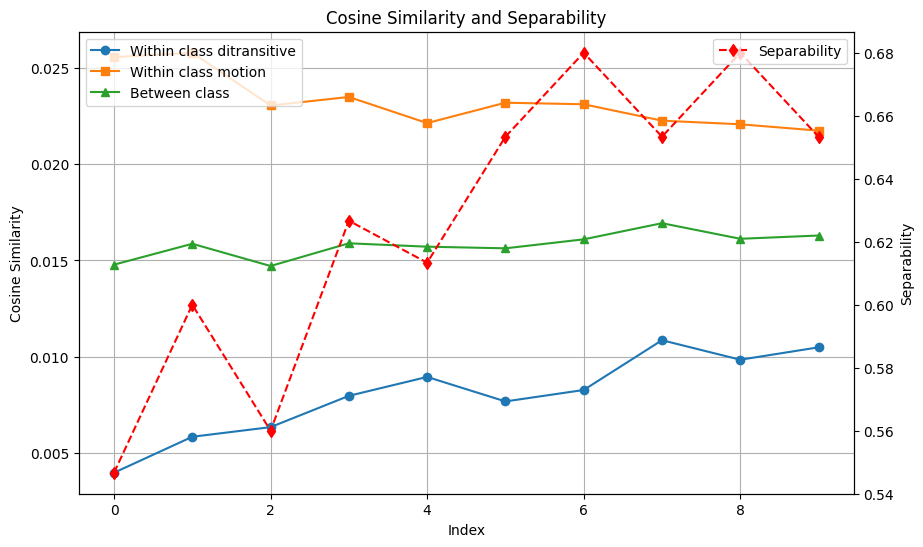

In [32]:
df3 = pd.DataFrame({"Within class ditransitive": cosine_ditrans_avg, "Within class motion": cosine_motion_avg, "Between class": cosine_between_avg, "Separability": separability})
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the cosine similarity metrics on the primary y-axis
ax1.plot(df3.index, df3["Within class ditransitive"], label="Within class ditransitive", marker="o")
ax1.plot(df3.index, df3["Within class motion"], label="Within class motion", marker="s")
ax1.plot(df3.index, df3["Between class"], label="Between class", marker="^")
ax1.set_ylabel("Cosine Similarity")
ax1.set_xlabel("Index")
ax1.legend(loc="upper left")
ax1.grid(True)

# Create a secondary y-axis for separability
ax2 = ax1.twinx()
ax2.plot(df3.index, df3["Separability"], label="Separability", color="red", linestyle="--", marker="d")
ax2.set_ylabel("Separability")
ax2.legend(loc="upper right")

# Show the plot
plt.title("Cosine Similarity and Separability")
plt.show()


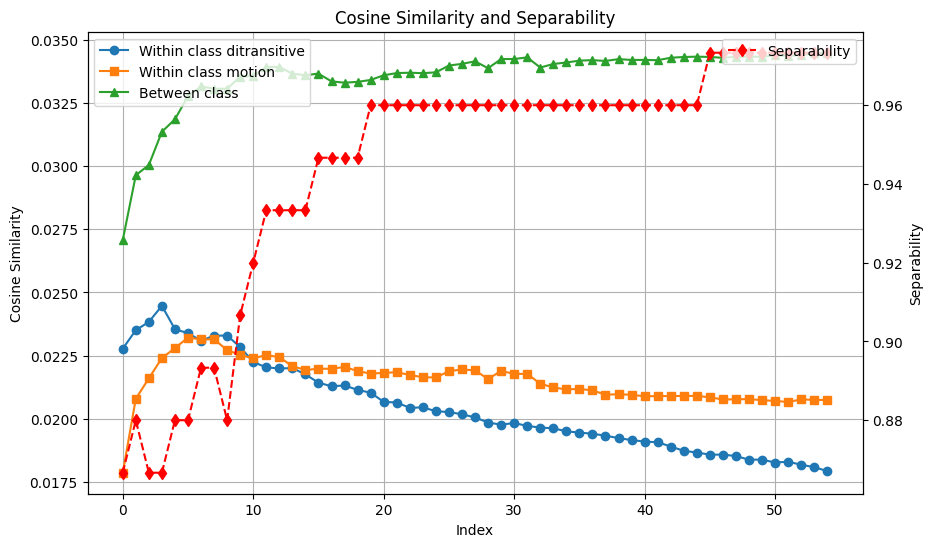

In [4]:
df2 = pd.DataFrame({"Within class ditransitive": cosine_ditrans_avg, "Within class motion": cosine_motion_avg, "Between class": cosine_between_avg, "Separability": separability})
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the cosine similarity metrics on the primary y-axis
ax1.plot(df2.index, df2["Within class ditransitive"], label="Within class ditransitive", marker="o")
ax1.plot(df2.index, df2["Within class motion"], label="Within class motion", marker="s")
ax1.plot(df2.index, df2["Between class"], label="Between class", marker="^")
ax1.set_ylabel("Cosine Similarity")
ax1.set_xlabel("Index")
ax1.legend(loc="upper left")
ax1.grid(True)

# Create a secondary y-axis for separability
ax2 = ax1.twinx()
ax2.plot(df2.index, df2["Separability"], label="Separability", color="red", linestyle="--", marker="d")
ax2.set_ylabel("Separability")
ax2.legend(loc="upper right")

# Show the plot
plt.title("Cosine Similarity and Separability")
plt.show()


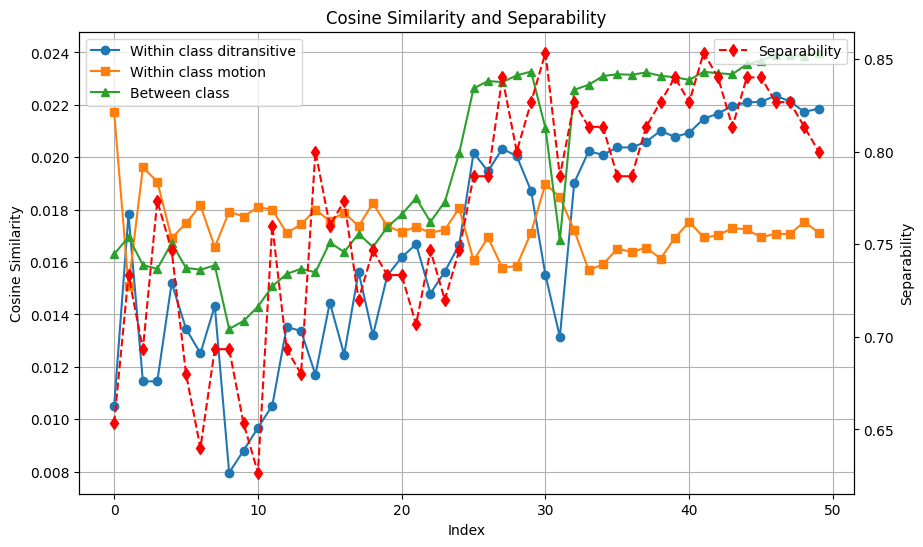

In [34]:
df1 = pd.DataFrame({"Within class ditransitive": cosine_ditrans_avg, "Within class motion": cosine_motion_avg, "Between class": cosine_between_avg, "Separability": separability})
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the cosine similarity metrics on the primary y-axis
ax1.plot(df1.index, df1["Within class ditransitive"], label="Within class ditransitive", marker="o")
ax1.plot(df1.index, df1["Within class motion"], label="Within class motion", marker="s")
ax1.plot(df1.index, df1["Between class"], label="Between class", marker="^")
ax1.set_ylabel("Cosine Similarity")
ax1.set_xlabel("Index")
ax1.legend(loc="upper left")
ax1.grid(True)

# Create a secondary y-axis for separability
ax2 = ax1.twinx()
ax2.plot(df1.index, df1["Separability"], label="Separability", color="red", linestyle="--", marker="d")
ax2.set_ylabel("Separability")
ax2.legend(loc="upper right")

# Show the plot
plt.title("Cosine Similarity and Separability")
plt.show()


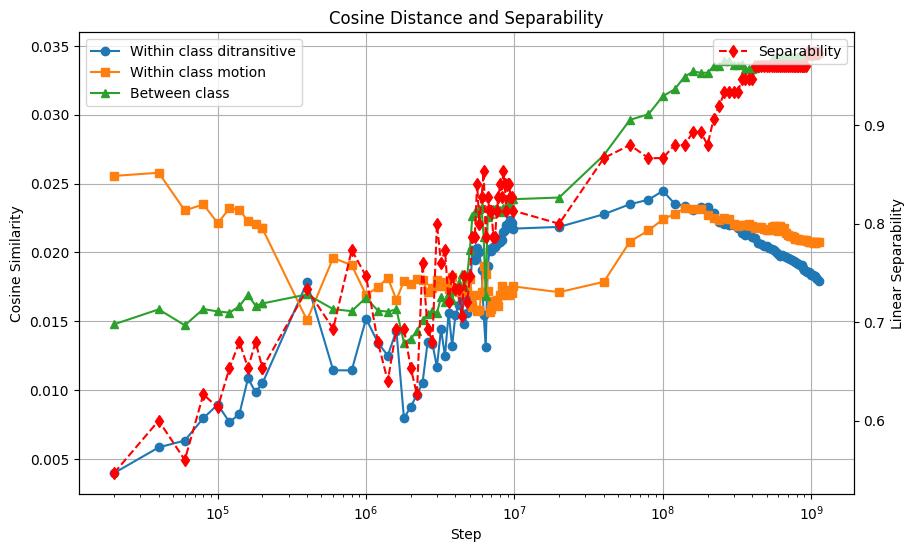

In [37]:
df_combined = pd.concat([df3, df1, df2], ignore_index=True)
indices = [x for x in range(20000, 220000, 20000)] + [x for x in range(200000, 10000000, 200000)] + [x for x in range(20000000, 1140000000, 20000000)]
df_combined.set_index(pd.Index(indices), inplace=True)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the cosine similarity metrics on the primary y-axis
ax1.plot(df_combined.index, df_combined["Within class ditransitive"], label="Within class ditransitive", marker="o")
ax1.plot(df_combined.index, df_combined["Within class motion"], label="Within class motion", marker="s")
ax1.plot(df_combined.index, df_combined["Between class"], label="Between class", marker="^")
ax1.set_ylabel("Cosine Similarity")
ax1.set_xlabel("Step")
ax1.legend(loc="upper left")
ax1.grid(True)
ax1.set_xscale("log")

# Create a secondary y-axis for separability
ax2 = ax1.twinx()
ax2.plot(df_combined.index, df_combined["Separability"], label="Separability", color="red", linestyle="--", marker="d")
ax2.set_ylabel("Linear Separability")
ax2.legend(loc="upper right")
ax2.set_xscale("log")
# Show the plot
plt.title("Cosine Distance and Separability")
plt.show()


In [53]:
# get the pairwise distances for the svd vectors
ditrans_distances = euclidean_distances(svd_ditrans_0, svd_ditrans_0)
motion_distances = euclidean_distances(svd_motion_0, svd_motion_0)
between_distances = euclidean_distances(svd_ditrans_0, svd_motion_0)

# get the average distance within class
ditrans_within = np.mean(ditrans_distances[np.triu_indices(len(ditrans_distances), k=1)])
motion_within = np.mean(motion_distances[np.triu_indices(len(motion_distances), k=1)])
print(f"Within class ditransitive: {ditrans_within:.2f}")
print(f"Within class motion: {motion_within:.2f}")

# get the average distance between class
between = np.mean(between_distances)
print(f"Between class: {between:.2f}")

Within class ditransitive: 0.15
Within class motion: 0.11
Between class: 0.14


Cumulative variance (first 4): 0.2246984398607111


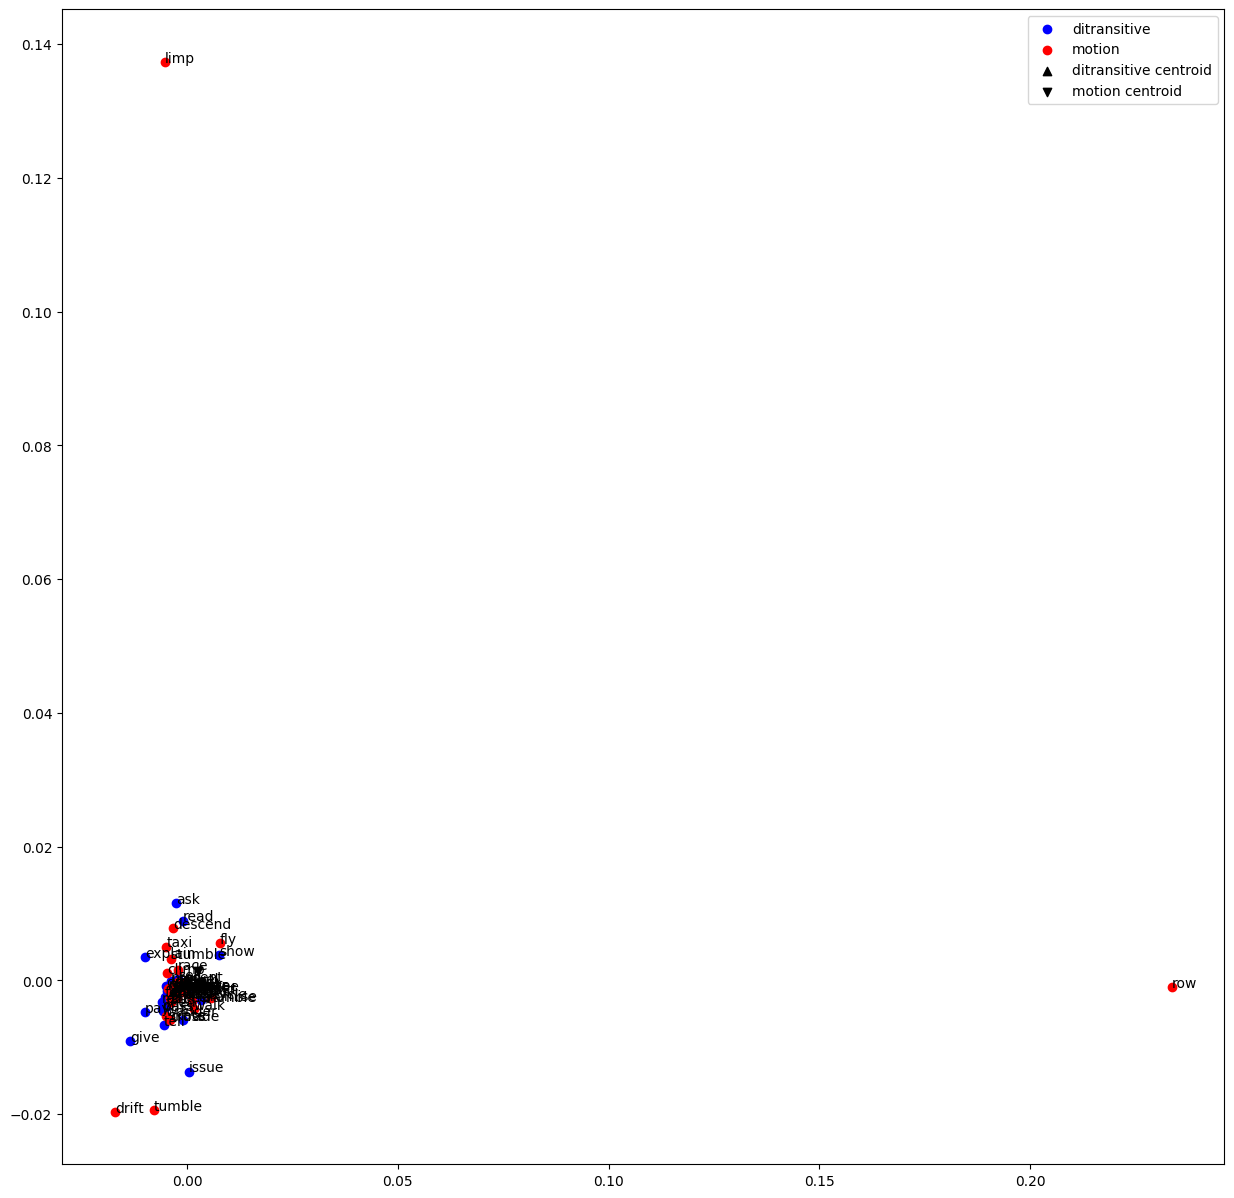

Separability: 0.56


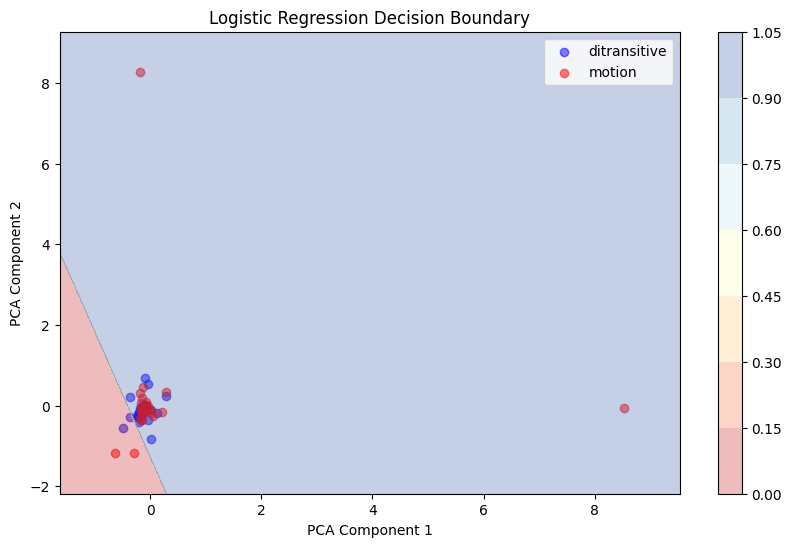

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# Load data
i = 6
svd_vectors_0 = np.load(f"/nlp/scr/jjian/datasets/openwebtext_filtered/word_vectors_earliest/openwebtext_co_matrix_0{i}.svd_l.propack.npy")
svd_ditrans_0 = [svd_vectors_0[x] for x in ditrans_mono]
svd_motion_0 = [svd_vectors_0[x] for x in motion_mono]

# partition the vectors into inflections with the same lemma
svd_ditrans_0 = [np.mean([svd_ditrans_0[x] for x in indices[1]], axis=0) for indices in ditrans_inflections_to_avg]
svd_motion_0 = [np.mean([svd_motion_0[x] for x in indices[1]], axis=0) for indices in motion_inflections_to_avg]

# PCA
pca = PCA(n_components=2)
pca.fit(svd_ditrans_0 + svd_motion_0)
transformed_ditrans = pca.transform(svd_ditrans_0)
transformed_motion = pca.transform(svd_motion_0)

# Check explained variance
#print(f"Explained variance: {pca.explained_variance_ratio_}")
# plot explained_variance_ratio
#plt.plot(np.cumsum(pca.explained_variance_ratio_))
#plt.xlabel('number of components')
#plt.ylabel('cumulative explained variance')
#plt.show()
print(f"Cumulative variance (first 4): {sum(pca.explained_variance_ratio_[:-1])}")
fig = plt.figure(figsize=(15, 15))
# 2D plot
plt.scatter(transformed_ditrans[:, 0], transformed_ditrans[:, 1], c='b', label='ditransitive')
plt.scatter(transformed_motion[:, 0], transformed_motion[:, 1], c='r', label='motion')

# Subword annotation (optional)
for i, txt in enumerate([x[0] for x in ditrans_inflections_to_avg]):
    plt.annotate(txt, (transformed_ditrans[i, 0], transformed_ditrans[i, 1]))
for i, txt in enumerate([x[0] for x in motion_inflections_to_avg]):
    plt.annotate(txt, (transformed_motion[i, 0], transformed_motion[i, 1]))

# Centroids
ditrans_centroid = np.mean(transformed_ditrans, axis=0)
motion_centroid = np.mean(transformed_motion, axis=0)

plt.scatter(ditrans_centroid[0], ditrans_centroid[1], c='k', marker='^', label='ditransitive centroid')
plt.scatter(motion_centroid[0], motion_centroid[1], c='k', marker='v', label='motion centroid')

plt.legend()
plt.show()

# Logistic regression
combined_vectors = np.vstack([transformed_ditrans, transformed_motion])
combined_vectors = combined_vectors[:, :]  # Use first 2 components
combined_labels = [0] * len(transformed_ditrans) + [1] * len(transformed_motion)

scaler = StandardScaler()
scaled_vectors = scaler.fit_transform(combined_vectors)

clf = LogisticRegression(C=10).fit(scaled_vectors, combined_labels)
fig = plt.figure(figsize=(10, 6))
print(f"Separability: {clf.score(scaled_vectors, combined_labels)}")
# Scatter plot with decision boundary
plt.scatter(scaled_vectors[:len(transformed_ditrans), 0], scaled_vectors[:len(transformed_ditrans), 1], c='b', label='ditransitive', alpha=0.5)
plt.scatter(scaled_vectors[len(transformed_ditrans):, 0], scaled_vectors[len(transformed_ditrans):, 1], c='r', label='motion', alpha=0.5)

x_min, x_max = scaled_vectors[:, 0].min() - 1, scaled_vectors[:, 0].max() + 1
y_min, y_max = scaled_vectors[:, 1].min() - 1, scaled_vectors[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.colorbar()
plt.legend()
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Logistic Regression Decision Boundary")
plt.show()
